In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Data Analysis

In [47]:
def load_and_impute(file_path):
    df = pd.read_csv(file_path)
    df_numeric = df.select_dtypes(include=[np.number])

    print('Missing values: ',df_numeric.isnull().sum())
    df_clean = df_numeric.fillna(df_numeric.mean())
    
    return df_clean

In [48]:
def standard_scaler(df):
    X = df.values

    means = np.mean(X, axis=0)
    stds = np.std(X, axis=0)

    stds[stds==0] = 1
    X_scaled = (X - means) / stds

    df_scaled = pd.DataFrame(X_scaled, columns=df.columns)

    return df_scaled, means, stds

In [49]:
file_path = 'AmesHousing.csv'

df = load_and_impute(file_path)

print(df.describe())

Missing values:  Order                0
PID                  0
MS SubClass          0
Lot Frontage       490
Lot Area             0
Overall Qual         0
Overall Cond         0
Year Built           0
Year Remod/Add       0
Mas Vnr Area        23
BsmtFin SF 1         1
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
1st Flr SF           0
2nd Flr SF           0
Low Qual Fin SF      0
Gr Liv Area          0
Bsmt Full Bath       2
Bsmt Half Bath       2
Full Bath            0
Half Bath            0
Bedroom AbvGr        0
Kitchen AbvGr        0
TotRms AbvGrd        0
Fireplaces           0
Garage Yr Blt      159
Garage Cars          1
Garage Area          1
Wood Deck SF         0
Open Porch SF        0
Enclosed Porch       0
3Ssn Porch           0
Screen Porch         0
Pool Area            0
Misc Val             0
Mo Sold              0
Yr Sold              0
SalePrice            0
dtype: int64
            Order           PID  MS SubClass  Lot Frontage       Lot Area

Plot relations

In [50]:
def plot_relations(df, feature_names, target_name):
    num_features = len(feature_names)
    plt.figure(figsize=(15, 5 * ((num_features + 2) // 3)))

    for i, col in enumerate(feature_names):
        plt.subplot(2, 3, i + 1)
        plt.scatter(df[col], df[target_name], alpha=0.5, c='blue', edgecolors='k', s=20)
        plt.title(f'{col} vs {target_name}')
        plt.xlabel(col)
        plt.ylabel(target_name)
        plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

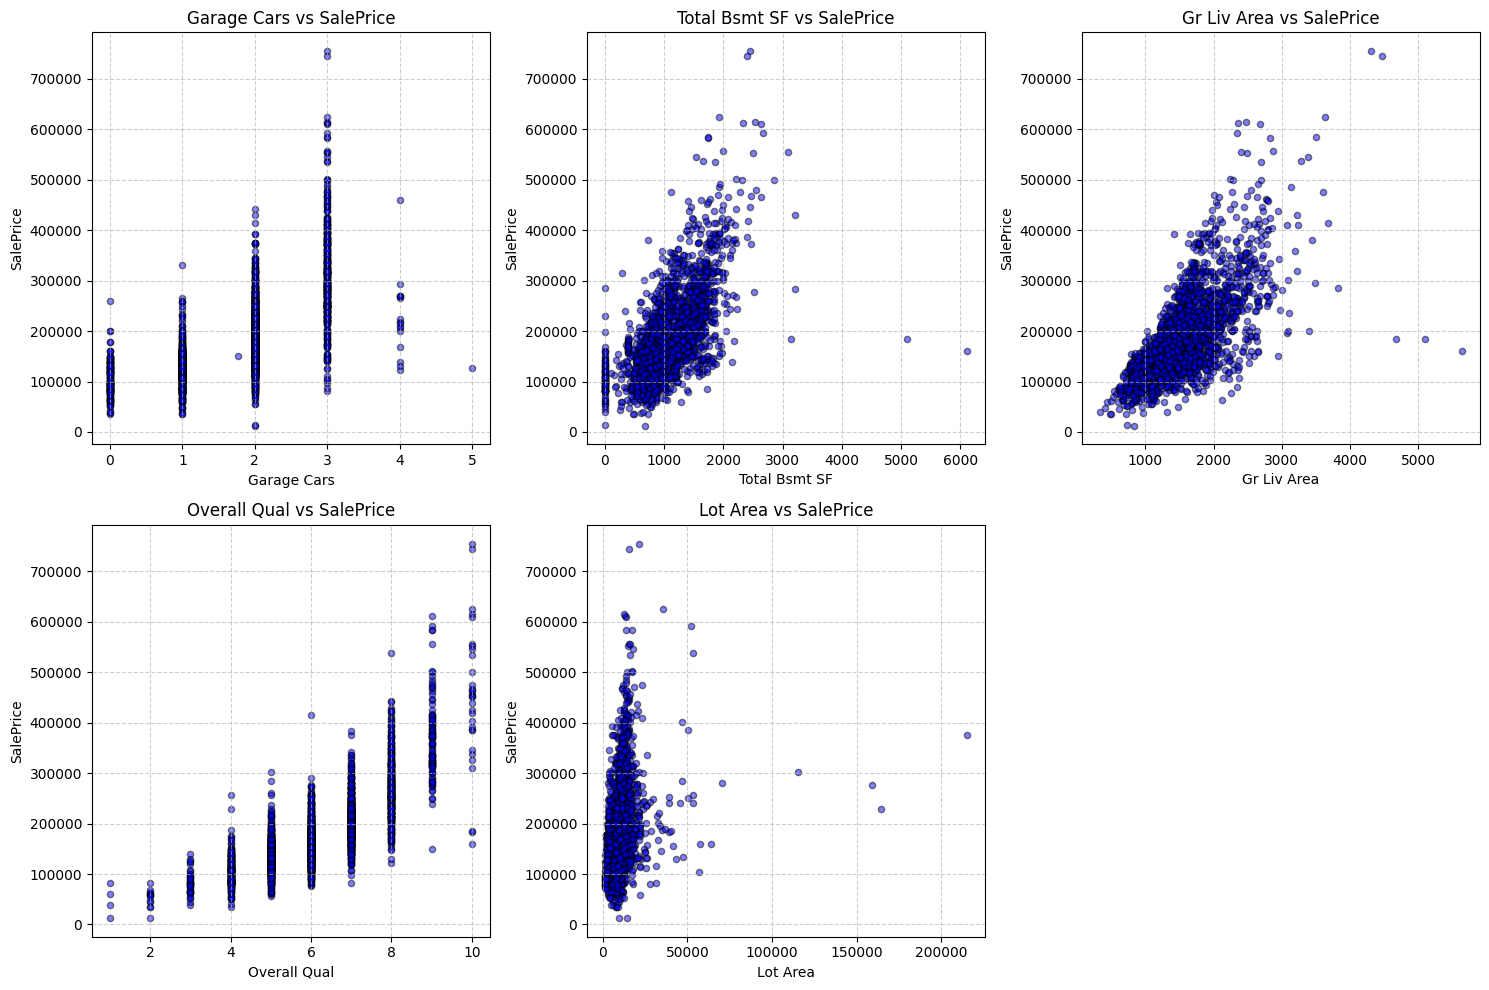

In [51]:
target_col = 'SalePrice'
features_to_analyze = ['Garage Cars', 'Total Bsmt SF', 'Gr Liv Area', 'Overall Qual', 'Lot Area']

plot_relations(df, features_to_analyze, target_col)

In [52]:
def train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42):
    np.random.seed(random_state)

    n_samples = X.shape[0]
    indices = np.random.permutation(n_samples)

    train_idx = indices[:int(train_ratio*n_samples)]
    val_idx = indices[int(train_ratio*n_samples) : int((train_ratio+val_ratio)*n_samples)]
    test_idx = indices[int((train_ratio+val_ratio)*n_samples):]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

In [53]:
class LinearRegressionSGD():
    def __init__(self, learning_rate=0.01, batch_size=32, n_epochs=500, reg_type=None, reg_lambda=0.0):
        self.lr = learning_rate
        self.batch_size= batch_size
        self.n_epochs = n_epochs
        self.reg_type = reg_type
        self.reg_lambda = reg_lambda

        self.weights = None
        self.bias = None
        self.history = {'train_loss': [], 'val_loss' : []}


    def _compute_loss(self, y_true, y_pred, weights):
        mse = np.mean((y_true - y_pred)**2)

        reg_term = 0
        if self.reg_type=='l2':
            reg_term = self.reg_lambda * np.sum(weights ** 2)
        elif self.reg_type == 'l1':
            reg_term = self.reg_lambda * np.sum(np.abs(weights))

        return mse + reg_term
    

    def _compute_gradients(self, X, y, y_pred, batch_len):
        error = y_pred - y
        
        dw = (2/batch_len) * np.dot(X.T, error)
        db = (2/batch_len) * np.sum(error)

        if self.reg_type == 'l1':
            dw += self.reg_lambda * np.sign(self.weights)
        elif self.reg_type == 'l2':
            dw += self.reg_lambda * self.weights * 2

        return dw, db
    

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias
    
    
    def fit(self, X_train, y_train, X_val, y_val):
        n_samples, n_features = X_train.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        patience_counter = 0
        best_val_loss = float('inf')
        last_val_loss = float('inf')

        for epoch in range(self.n_epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i : i + self.batch_size]
                y_batch = y_shuffled[i : i + self.batch_size]

                y_pred = np.dot(X_batch, self.weights) + self.bias

                dw, db = self._compute_gradients(X_batch, y_batch, y_pred, len(X_batch))

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            train_pred = self.predict(X_train)
            val_pred = self.predict(X_val)

            train_loss = self._compute_loss(y_train, train_pred, self.weights)
            val_loss = self._compute_loss(y_val, val_pred, self.weights)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)

            if val_loss > last_val_loss:
                patience_counter += 1
            else:
                patience_counter = 0

            last_val_loss = val_loss
            
            if patience_counter >= 3 :
                break

In [54]:
def run_experiment(X, y, config, seed):

    X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=seed)

    model = LinearRegressionSGD(
        learning_rate=config['lr'],
        batch_size=config['batch_size'],
        n_epochs=500,
        reg_type=config['reg_type'],
        reg_lambda=config['lambda']
        )
    
    model.fit(X_train, y_train, X_val, y_val)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    train_mse = np.mean((y_train - train_pred)**2)
    val_mse = np.mean((y_val - val_pred)**2)
    test_mse = np.mean((y_test - test_pred)**2)

    converged_epoch = len(model.history['train_loss'])
    history = model.history

    return{
        'epochs' : converged_epoch,
        'train_mse' : train_mse,
        'val_mse' : val_mse,
        'test_mse' : test_mse,
        'history' : history,
        'final_weights' : model.weights
    }

In [55]:
def compute_seeds(X, y, config):
    seeds = range(10)
    metrics = {'train_mse': [], 'val_mse' : [], 'test_mse': [], 'epochs': []}

    for seed in seeds:
        res = run_experiment(X, y, config, seed)

        metrics['train_mse'].append(res['train_mse'])
        metrics['val_mse'].append(res['val_mse'])
        metrics['test_mse'].append(res['test_mse'])
        metrics['epochs'].append(res['epochs'])

        last_weights = res['final_weights']
        
        summary = {
        'config': config,
        'avg_train_mse': np.mean(metrics['train_mse']),
        'avg_test_mse': np.mean(metrics['test_mse']),
        'std_test_mse': np.std(metrics['test_mse']),
        'avg_epochs': np.mean(metrics['epochs']),
        'last_weights': last_weights
    }
    return summary


In [56]:
df_scaled, means, stds = standard_scaler(df)

X_scaled = df_scaled.drop(columns=[target_col]).values
y_scaled = df_scaled[target_col].values

X_raw = df.drop(columns=[target_col]).values
y_raw = df[target_col].values

batch_sizes = [1, 16, 64]
learning_rates = [0.01, 0.001]
reg_lambdas = [0.01, 0.1, 1, 10]
reg_types= [None, 'l1', 'l2']
n_epochs = 500

results_scaled = []
results_raw = []

configs = []

for bs in batch_sizes:
    for lr in learning_rates:
        configs.append({'batch_size': bs, 'lr': lr, 'reg_type' : None, 'lambda': 0 })
        for r_type in ['l1', 'l2']:
            for lam in reg_lambdas:
                configs.append({'batch_size' : bs, 'lr' : lr, 'reg_type' : r_type, 'lambda' : lam})
            

for i, conf in enumerate(configs):
    summary_scaled = compute_seeds(X_scaled, y_scaled, conf)
    results_scaled.append(summary_scaled)
    
    # summary_raw = compute_seeds(X_raw, y_raw, conf)
    # results_raw.append(summary_raw)

results_df = pd.DataFrame([
    { 
        'Batch': r['config']['batch_size'],
        'LR': r['config']['lr'],
        'Type': r['config']['reg_type'],
        'Lambda': r['config']['lambda'],
        'Test MSE': r['avg_test_mse'],
        'Stability (Std)': r['std_test_mse'],
        'Avg Epochs': r['avg_epochs']  
    } for r in results_scaled
])

# results_df_raw = pd.DataFrame([
#     { 
#         'Batch': r['config']['batch_size'],
#         'LR': r['config']['lr'],
#         'Type': r['config']['reg_type'],
#         'Lambda': r['config']['lambda'],
#         'Test MSE': r['avg_test_mse'],
#         'Stability (Std)': r['std_test_mse'],
#         'Avg Epochs': r['avg_epochs']  
#     } for r in results_raw
# ])

In [57]:
print(results_df.sort_values(by='Test MSE').head(5))

    Batch     LR Type  Lambda  Test MSE  Stability (Std)  Avg Epochs
47     64  0.001   l1    0.10  0.264105         0.086582        69.4
29     16  0.001   l1    0.10  0.269310         0.088944        33.4
42     64  0.010   l2    0.10  0.269557         0.120908        28.4
46     64  0.001   l1    0.01  0.270090         0.118132        50.1
38     64  0.010   l1    0.10  0.271017         0.095467        35.2


In [58]:
best_result = sorted(results_scaled, key=lambda x: x['avg_test_mse'])[0]
print(f"Best Config: {best_result['config']}")

feature_names = df_scaled.drop(columns=[target_col]).columns

best_weights = best_result['last_weights']

weights_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': best_weights,
    'Abs_Weight': np.abs(best_weights)
})

weights_df = weights_df.sort_values(by='Abs_Weight', ascending=False)

print("\nTop Features:")
print(weights_df.head(10))

print("\nIgnored Features via L1:")
zero_features = weights_df[weights_df['Abs_Weight'] < 1e-3]
print(zero_features[['Feature', 'Weight']])


Best Config: {'batch_size': 64, 'lr': 0.001, 'reg_type': 'l1', 'lambda': 0.1}

Top Features:
           Feature    Weight  Abs_Weight
5     Overall Qual  0.321934    0.321934
17     Gr Liv Area  0.225102    0.225102
8   Year Remod/Add  0.074778    0.074778
14      1st Flr SF  0.065263    0.065263
13   Total Bsmt SF  0.064784    0.064784
27     Garage Cars  0.064473    0.064473
10    BsmtFin SF 1  0.058156    0.058156
28     Garage Area  0.053334    0.053334
9     Mas Vnr Area  0.052540    0.052540
7       Year Built  0.047057    0.047057

Ignored Features via L1:
            Feature    Weight
33     Screen Porch  0.000486
24    TotRms AbvGrd  0.000355
15       2nd Flr SF  0.000308
6      Overall Cond  0.000221
30    Open Porch SF  0.000187
22    Bedroom AbvGr -0.000167
19   Bsmt Half Bath -0.000155
0             Order  0.000115
1               PID  0.000106
12      Bsmt Unf SF -0.000098
37          Yr Sold  0.000081
11     BsmtFin SF 2  0.000078
36          Mo Sold -0.000068
16  Low Qu

Standardize effects

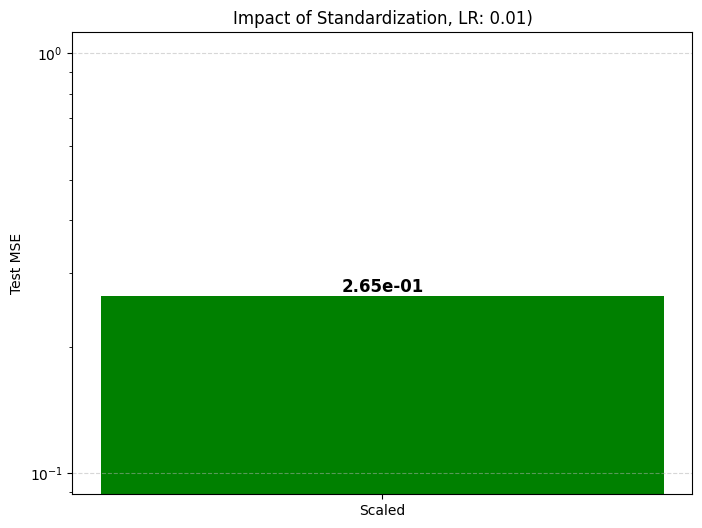

In [ ]:
best_idx = results_df['Test MSE'].idxmin()
best_scaled_mse = results_df.loc[best_idx, 'Test MSE']
corresponding_raw_mse = results_df_raw.loc[best_idx, 'Test MSE']

values = [best_scaled_mse, corresponding_raw_mse]
names = ['Scaled', 'Raw']
colors = ['green', 'red']

plt.figure(figsize=(8, 6))
bars = plt.bar(names, values, color=colors, width=0.5)

plt.yscale('log') 
plt.ylabel('Test MSE')
plt.title(f'Impact of Standardization, LR: {results_df.loc[best_idx, "LR"]})')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2e}', 
             va='bottom', ha='center', fontweight='bold', fontsize=12)

plt.show()


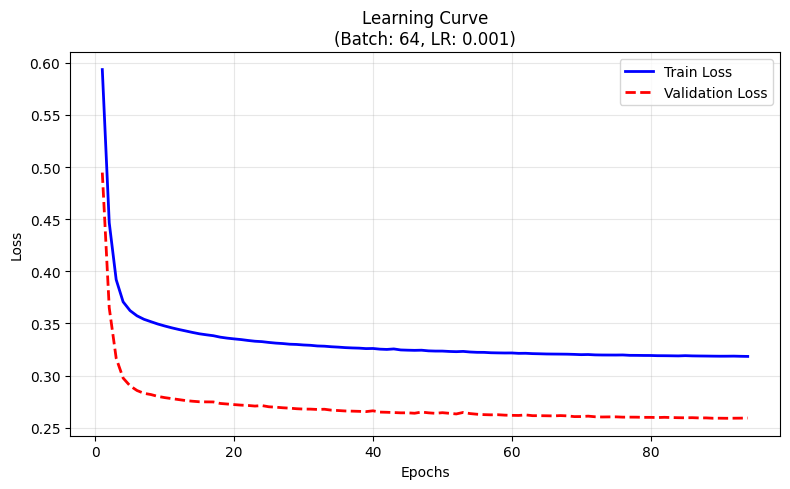

In [61]:
config = best_result['config']

print("")
result = run_experiment(X_scaled, y_scaled, config, seed=42)

history = result['history']
train_loss = history['train_loss']
val_loss = history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', color='red', linestyle='--', linewidth=2)

plt.title(f"Learning Curve\n(Batch: {config['batch_size']}, LR: {config['lr']})")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Grid Search Visualization

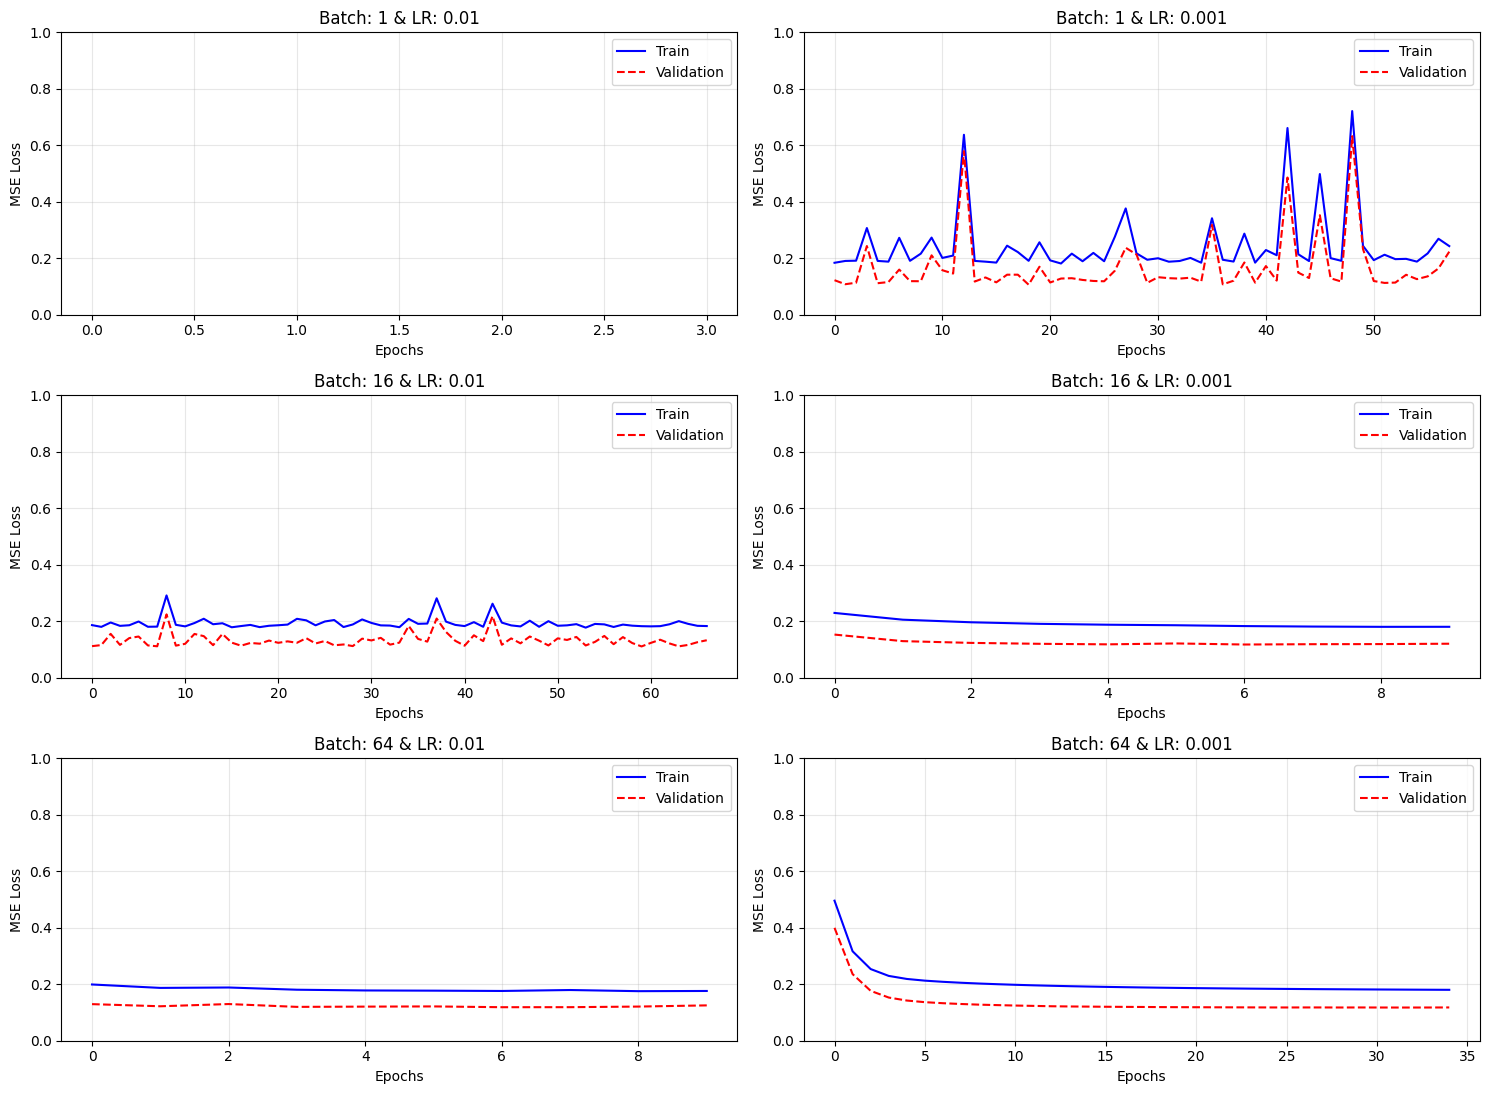

In [65]:
fig, axes = plt.subplots(len(batch_sizes), len(learning_rates), figsize=(15, 12))

X_train, y_train, X_val, y_val, _, _ = train_test_split(X_scaled, y_scaled, train_ratio=0.8, val_ratio=0.1, random_state=42)

for i, batch_size in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        ax = axes[i, j]
        
        model = LinearRegressionSGD(learning_rate=lr, batch_size=batch_size, n_epochs=100, reg_type=None)
        
        try:
            model.fit(X_train, y_train, X_val, y_val)
            train_loss = model.history['train_loss']
            val_loss = model.history['val_loss']
            
            ax.plot(train_loss, label='Train', color='blue')
            ax.plot(val_loss, label='Validation', color='red', linestyle='--')
            
            final_loss = train_loss[-1] if train_loss else float('inf')
            status = f"Final Train Loss: {final_loss:.4f}"
            
        except Exception as e:
            status = "Diverged (Exploded)"
        
        ax.set_title(f"Batch: {batch_size} & LR: {lr}")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("MSE Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        ax.set_ylim(0, 1.0) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Lambda effect

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

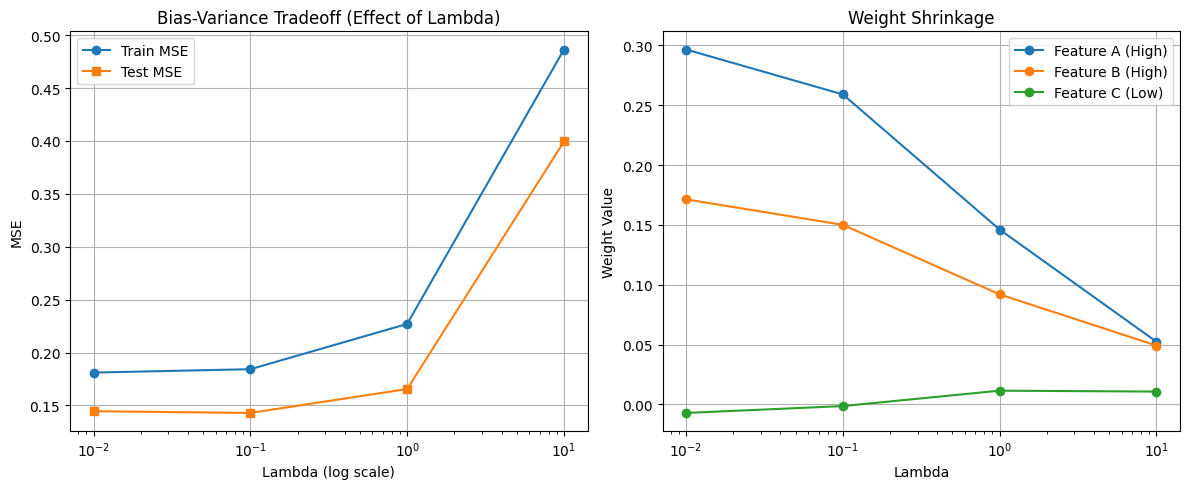

In [63]:
train_errors = []
test_errors = []
weights_history = []

feature_indices = [5, 17, 12]

for lam in reg_lambdas:
    model = LinearRegressionSGD(learning_rate=0.01, batch_size=64, n_epochs=300, reg_type='l2', reg_lambda=lam)

    X_tr, y_tr, X_v, y_v, X_te, y_te = train_test_split(X_scaled, y_scaled, 0.8, 0.1, random_state=42)
    model.fit(X_tr, y_tr, X_v, y_v)

    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    train_errors.append(np.mean((y_tr - train_pred)**2))
    test_errors.append(np.mean((y_te - test_pred)**2))

    weights_history.append(model.weights[feature_indices])

    plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(reg_lambdas, train_errors, 'o-', label='Train MSE')
plt.plot(reg_lambdas, test_errors, 's-', label='Test MSE')
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('MSE')
plt.title('Bias-Variance Tradeoff (Effect of Lambda)')
plt.legend()
plt.grid(True)


weights_history = np.array(weights_history)
plt.subplot(1, 2, 2)
labels = ["Feature A (High)", "Feature B (High)", "Feature C (Low)"]
for i in range(3):
    plt.plot(reg_lambdas, weights_history[:, i], marker='o', label=labels[i])
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Weight Value')
plt.title('Weight Shrinkage')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()